## <strong>第三次作品：AT&T 人臉辨識模型的準確率與維度權衡分析</strong>
**實作者：Felix**
<hr>

<font color=skyblue>作品目標</font>：本作品以 AT&T Face Dataset 為核心資料，探討三種監督式分類模型－邏輯斯迴歸（Logistic Regression）、支援向量機（Support Vector Machine, SVM）與神經網路（Neural Network, NN）在人臉影像辨識任務中的效能表現。資料集包含 400 張 64×64 灰階人臉影像，共 40 位人物，每張影像展平成 4096 維特徵。本作品先統一完成資料讀取、訓練/測試切分、標準化與主成分分析（PCA），再比較原始資料、PCA 70%、PCA 80% 與 PCA 95% 條件下的模型準確率、訓練時間與分類穩定性。

| 分析主題 | 實作重點 | 評估指標 |
|---|---|---|
| 共用前處理 | 影像展示、標準化、PCA 解釋變異分析 | 主成分數、累積解釋變異比例 |
| 模型與 PCA 比例分析 | 原始資料模型比較、GridSearchCV、PCA 70% vs 80% | 測試準確率、訓練時間 |
| 三分類器深度評比 | MLR / SVM / NN 在原始資料與 PCA 95% 下比較 | 混淆矩陣、測試準確率、訓練時間 |


#### **<font color="blue">1. 共用前處理：人臉影像展示、標準化與主成分分析（PCA）</font>**

##### **<font color="lightblue">(1) 統一套件匯入與執行環境設定</font>**

In [1]:
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

warnings.filterwarnings("ignore")

# 設定中文字體，避免圖表中文字與負號顯示異常。
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["font.family"] = "Microsoft JhengHei"
plt.rcParams["axes.unicode_minus"] = False

# 讓 notebook 從「作品三」根目錄或 data 目錄執行時，都能使用指定的讀取語法。
if Path("data/face_data.csv").exists():
    os.chdir("data")

#### <u><strong>程式碼說明：統一套件匯入與資料路徑定位</strong></u>

##### **1. 概述**
本區塊集中匯入後續所有實驗需要的套件，避免在不同分析段落重複 import。

##### **2. 流程/設定說明**
| 設定項目 | 說明 |
|---|---|
| 中文字體 | 保留 `Microsoft JhengHei`，確保繁體中文圖表標籤可正常顯示 |
| 資料目錄 | 若從根目錄執行，會先切換到 `data` 目錄 |
| 資料讀取規則 | 後續嚴格使用 `df = pd.read_csv('face_data.csv')` 作為唯一資料來源 |



##### **<font color="lightblue">(2) 人臉影像展示</font>**

資料維度：(400, 4096)
影像尺寸：64 x 64
樣本數：400
特徵數：4096
人物類別數：40


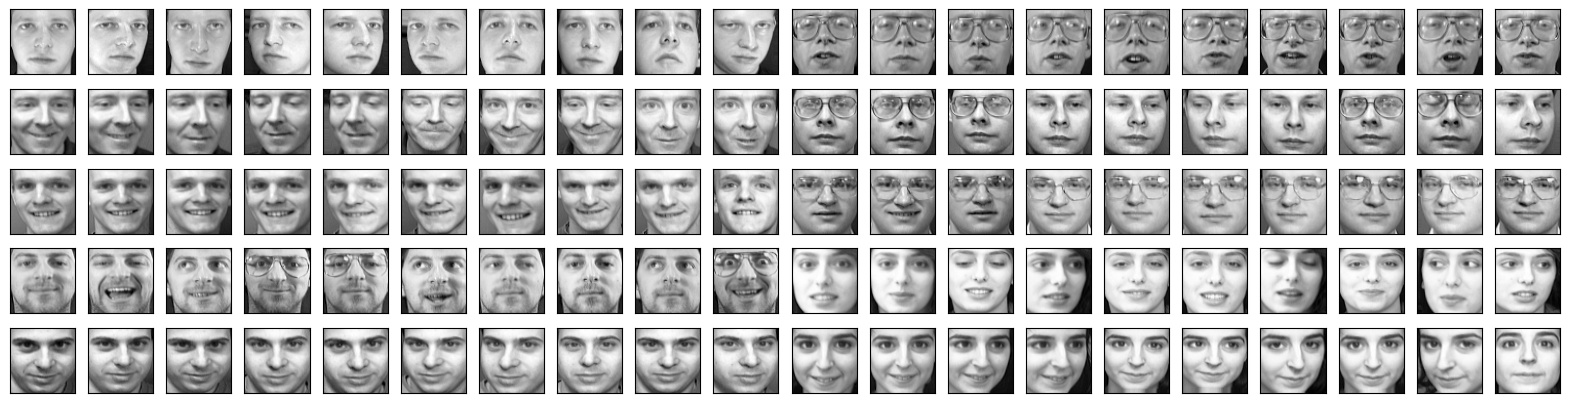

In [2]:
def show_montage(X, n, m, h, w):
    '''
    X: image matrix in which each column represents an image
    n, m: image size n x m
    h, w : create an h x w montage image with figsize = (w,h)
    '''
    fig, axes = plt.subplots(h, w, figsize=(w, h))
    if X.shape[1] < w * h:
        X = np.c_[X, np.zeros((X.shape[0], w * h - X.shape[1]))]
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[:, i].reshape(n, m), cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()


df = pd.read_csv("face_data.csv")
X = df.drop("target", axis=1).values
y = df["target"].values
n, m = 64, 64
n_persons = df["target"].nunique()

print(f"資料維度：{X.shape}")
print(f"影像尺寸：{n} x {m}")
print(f"樣本數：{X.shape[0]}")
print(f"特徵數：{X.shape[1]}")
print(f"人物類別數：{n_persons}")

show_montage(X.T, n, m, 5, 20)

#### <u><strong>圖表/程式碼說明：AT&T 人臉資料集影像展示</strong></u>

##### **1. 概述**
本區塊使用 AT&T 人臉資料集（AT&T Face Dataset）作為唯一資料來源，共包含 400 張、64×64、4096 維的人臉影像，類別為 40 人。

##### **2. 流程/設定說明**
| 步驟 | 設定 | 說明 |
|---|---:|---|
| 讀取資料 | `pd.read_csv('face_data.csv')` | 讀取 CSV |
| 特徵矩陣 | 400×4096 | 每列為一張展平後的人臉影像 |
| 標籤向量 | 400 | `target` 欄位為人物類別 |
| 影像展示 | 5×20 | 使用 `show_montage` 顯示部分人臉 |

##### **3. 結果觀察**
影像皆可還原為 64×64 灰階人臉，確認 CSV 內容可直接支援後續分類與主成分分析（PCA）。

##### **<font color="lightblue">(3) Train/Test Split、標準化與 PCA 解釋變異</font>**

X_train_ shape: (280, 4096)
X_test_ shape: (120, 4096)
保留 70% 解釋變異所需主成分數：14
保留 80% 解釋變異所需主成分數：26
保留 95% 解釋變異所需主成分數：106


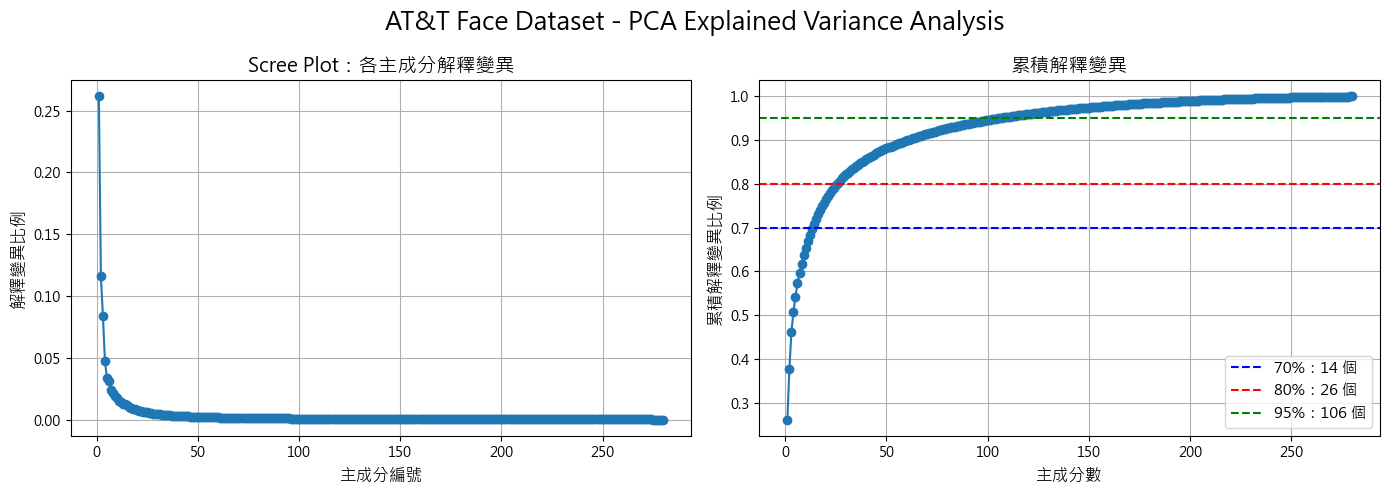

In [3]:
test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42
)

scaler = StandardScaler()
X_train_ = scaler.fit_transform(X_train)
X_test_ = scaler.transform(X_test)

# 三分類器深度評比沿用的命名，代表標準化後但尚未 PCA 降維的原始特徵。
X_train_original = X_train_.copy()
X_test_original = X_test_.copy()

# PCA 全成分只 fit 一次，後續 70%、80%、95% 都由同一個 pca 物件轉換後切片取得。
pca = PCA()
pca.fit(X_train_)
explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

n_components_70 = int(np.argmax(cum_explained_var >= 0.70) + 1)
n_components_80 = int(np.argmax(cum_explained_var >= 0.80) + 1)
n_components_95 = int(np.argmax(cum_explained_var >= 0.95) + 1)

X_train_pca_all = pca.transform(X_train_)
X_test_pca_all = pca.transform(X_test_)
X_train_pca_70 = X_train_pca_all[:, :n_components_70]
X_test_pca_70 = X_test_pca_all[:, :n_components_70]
X_train_pca_80 = X_train_pca_all[:, :n_components_80]
X_test_pca_80 = X_test_pca_all[:, :n_components_80]
X_train_pca = X_train_pca_all[:, :n_components_95]
X_test_pca = X_test_pca_all[:, :n_components_95]

print(f"X_train_ shape: {X_train_.shape}")
print(f"X_test_ shape: {X_test_.shape}")
print(f"保留 70% 解釋變異所需主成分數：{n_components_70}")
print(f"保留 80% 解釋變異所需主成分數：{n_components_80}")
print(f"保留 95% 解釋變異所需主成分數：{n_components_95}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AT&T Face Dataset - PCA Explained Variance Analysis", fontsize=18)

axes[0].plot(range(1, len(explained_var) + 1), explained_var, marker="o")
axes[0].set_title("Scree Plot：各主成分解釋變異", fontsize=14)
axes[0].set_xlabel("主成分編號", fontsize=12)
axes[0].set_ylabel("解釋變異比例", fontsize=12)
axes[0].grid(True)

axes[1].plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker="o")
axes[1].axhline(y=0.70, color="blue", linestyle="--", label=f"70%：{n_components_70} 個")
axes[1].axhline(y=0.80, color="red", linestyle="--", label=f"80%：{n_components_80} 個")
axes[1].axhline(y=0.95, color="green", linestyle="--", label=f"95%：{n_components_95} 個")
axes[1].set_title("累積解釋變異", fontsize=14)
axes[1].set_xlabel("主成分數", fontsize=12)
axes[1].set_ylabel("累積解釋變異比例", fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### <u><strong>圖表/程式碼說明：共用前處理與主成分分析（PCA）</strong></u>

##### **1. 概述**
本區塊只執行一次資料切分、標準化與主成分分析（PCA），後續「模型與 PCA 比例分析」與「三分類器深度評比」均沿用相同資料。

##### **2. 流程/設定說明**
| 前處理項目 | 設定 | 輸出變數 |
|---|---|---|
| 訓練/測試切分 | `test_size=0.3`, `random_state=42` | `X_train`, `X_test`, `y_train`, `y_test` |
| 標準化 | 訓練集 `fit_transform`、測試集 `transform` | `X_train_`, `X_test_` |
| PCA | 全成分只 fit 一次 | `pca`, `explained_var`, `cum_explained_var` |
| PCA 門檻 | 70%、80%、95% | `n_components_70`, `n_components_80`, `n_components_95` |

##### **3. 結果觀察**
測試集標準化使用 `scaler.transform(X_test)`，避免測試資料資訊外洩；PCA 轉換則由同一個全成分模型產生，確保各比例分析使用一致的特徵基準。


##### **<font color="lightblue">(4) 共用視覺化函數</font>**

In [4]:
def plot_classifier(df, title, y_col="測試準確率", y_label=None,
                    y_format="percent", y_lim=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    data_types = df["資料版本"].unique()
    settings = df["設定"].unique()
    x = np.arange(len(data_types))
    width = 0.8 / len(settings)

    for idx, setting in enumerate(settings):
        values = []
        for data_type in data_types:
            row = df[(df["資料版本"] == data_type) & (df["設定"] == setting)]
            values.append(row[y_col].iloc[0] if len(row) else np.nan)

        offset = (idx - (len(settings) - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, label=setting)

        for bar, value in zip(bars, values):
            if np.isnan(value):
                continue
            label = f"{value:.2%}" if y_format == "percent" else f"{value:.2f}"
            ax.annotate(
                label,
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(data_types, fontsize=11)
    ax.set_ylabel(y_label or y_col, fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(title="設定", fontsize=9)
    if y_lim is not None:
        ax.set_ylim(y_lim)


def plot_confusion_matrices(models, X_tests, y_test, titles=None, n_cols=2):
    n_models = len(models)
    n_rows = (n_models + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, (model, X_eval) in enumerate(zip(models, X_tests)):
        y_pred = model.predict(X_eval)
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            normalize="true",
            cmap=plt.cm.Purples,
            include_values=False,
            ax=axes[i],
        )
        title = titles[i] if titles and i < len(titles) else f"模型 {i + 1}"
        axes[i].set_title(f"Confusion Matrix ({title})", fontsize=13)
        axes[i].set_xlabel("Predicted", fontsize=11)
        axes[i].set_ylabel("True", fontsize=11)
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha="right", fontsize=8)
        plt.setp(axes[i].get_yticklabels(), rotation=45, ha="right", fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

#### <u><strong>程式碼說明：共用視覺化函數</strong></u>

##### **1. 概述**
本區塊定義分類器深度評比需要的長條圖與混淆矩陣函數，並只定義一次。

##### **2. 流程/設定說明**
| 函數 | 用途 | 輸入重點 |
|---|---|---|
| `plot_classifier` | 比較不同資料版本與設定的準確率或時間 | `DataFrame`、欄位名稱、座標軸 |
| `plot_confusion_matrices` | 同時呈現多個模型的正規化混淆矩陣 | 已訓練模型、測試資料、真實標籤 |

##### **3. 結果觀察**
這兩個函數後續會被多元羅吉斯回歸（MLR）、支援向量機（SVM）與神經網路（NN）評比段落共用。


#### **<font color="blue">2. 模型與 PCA 比例分析</font>**

##### **<font color="lightblue">(1) 原始資料下各模型十次重複實驗</font>**


,模型名稱,平均測試準確率,標準差
0,LinearSVC,0.883333,0.000000
1,Logistic Regression,0.966667,0.000000
2,Logistic RegressionCV,0.950000,0.000000
3,MLPClassifier,0.895833,0.023976
4,SVC,0.966667,0.000000


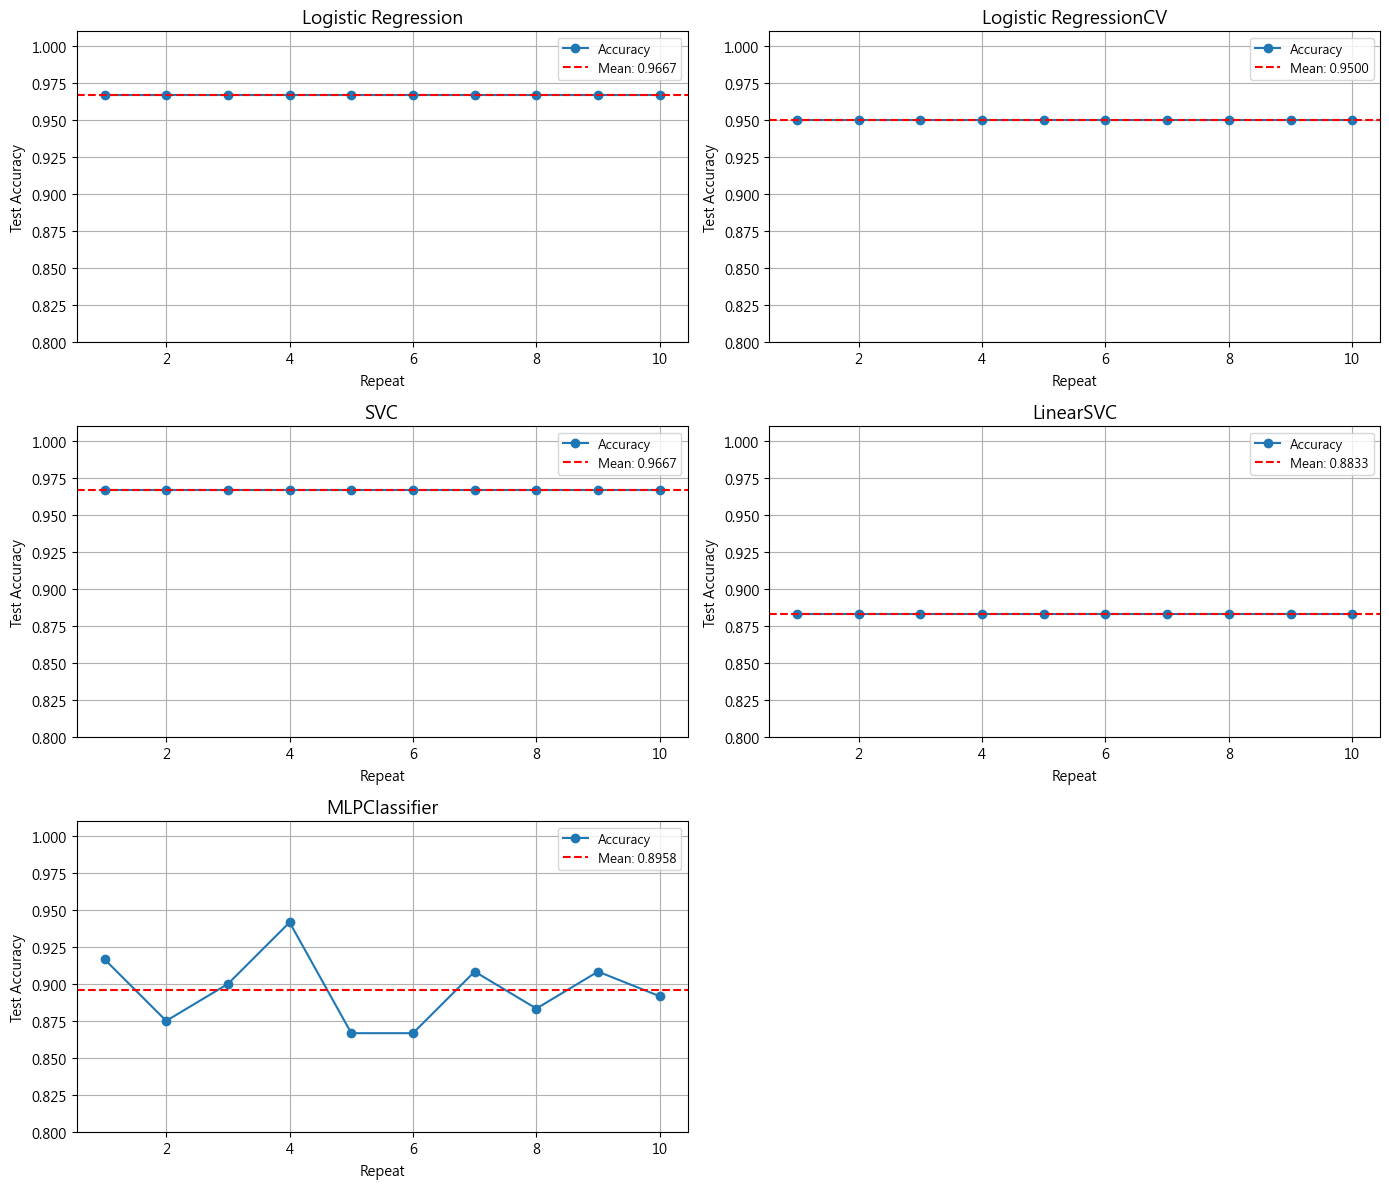

In [5]:
n_repeats = 10
part_a_original_rows = []

original_models = {
    "Logistic Regression": LogisticRegression(solver="lbfgs", max_iter=1000),
    "Logistic RegressionCV": LogisticRegressionCV(cv=5, solver="lbfgs", max_iter=1000, n_jobs=-1),
    "SVC": SVC(kernel="linear", max_iter=10000),
    "LinearSVC": LinearSVC(max_iter=10000),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(100,), activation="relu", solver="adam", max_iter=1000),
}

for repeat in range(1, n_repeats + 1):
    for model_name, model in original_models.items():
        clf = clone(model)
        if hasattr(clf, "random_state"):
            clf.set_params(random_state=repeat + 399)
        clf.fit(X_train_, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test_))
        part_a_original_rows.append({
            "重複次數": repeat,
            "模型名稱": model_name,
            "測試準確率": acc,
        })

part_a_original_results = pd.DataFrame(part_a_original_rows)
part_a_original_summary = (
    part_a_original_results
    .groupby("模型名稱")["測試準確率"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "平均測試準確率", "std": "標準差"})
)
display(part_a_original_summary)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.reshape(-1)
for ax, model_name in zip(axes, original_models.keys()):
    data = part_a_original_results[part_a_original_results["模型名稱"] == model_name]
    ax.plot(data["重複次數"], data["測試準確率"], marker="o", label="Accuracy")
    ax.axhline(data["測試準確率"].mean(), color="r", linestyle="--",
               label=f"Mean: {data['測試準確率'].mean():.4f}")
    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Repeat")
    ax.set_ylabel("Test Accuracy")
    ax.set_ylim(0.8, 1.01)
    ax.grid(True)
    ax.legend(fontsize=9)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

#### <u><strong>圖表/程式碼說明：原始資料下各模型十次重複實驗</strong></u>

##### **1. 概述**
本段比較邏輯斯迴歸（Logistic Regression）、交叉驗證邏輯斯迴歸（Logistic RegressionCV）、支援向量機（SVM）與多層感知器（MLP）在原始標準化特徵上的表現。

##### **2. 流程/設定說明**
| 項目 | 設定 | 說明 |
|---|---|---|
| 資料版本 | 原始標準化資料 | 使用共用 `X_train_` 與 `X_test_` |
| 重複次數 | 10 次 | 不重複切分資料，只重複模型訓練與評估 |
| 評估指標 | 測試準確率 | 以 `accuracy_score` 計算 |

##### **3. 結果觀察**
線性模型與線性支援向量機通常在人臉高維特徵下具備穩定表現；神經網路則較受初始化與最佳化過程影響。

##### **<font color="lightblue">(2) GridSearchCV 超參數調整</font>**

In [6]:
part_a_grid_rows = []
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=0)

grid_specs = [
    (
        "Logistic Regression",
        LogisticRegression(tol=1e-6, max_iter=int(1e6)),
        {"solver": ["lbfgs", "newton-cg"], "C": [0.1, 1, 10]},
    ),
    (
        "SVC",
        SVC(),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf", "poly"],
            "gamma": ["scale", "auto"],
            "decision_function_shape": ["ovo", "ovr"],
        },
    ),
    (
        "MLPClassifier",
        MLPClassifier(max_iter=1000, random_state=0),
        {
            "hidden_layer_sizes": [(50,), (100,), (100, 50)],
            "activation": ["relu", "tanh"],
            "solver": ["adam", "lbfgs"],
            "alpha": [0.0001, 0.001],
        },
    ),
]

part_a_grids = {}
for model_name, estimator, param_grid in grid_specs:
    start_time = time.time()
    grid_model = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        refit="accuracy",
        n_jobs=-1,
    )
    grid_model.fit(X_train_, y_train)
    elapsed = time.time() - start_time
    part_a_grids[model_name] = grid_model
    part_a_grid_rows.append({
        "模型名稱": model_name,
        "最佳參數": grid_model.best_params_,
        "交叉驗證準確率": grid_model.best_score_,
        "測試準確率": accuracy_score(y_test, grid_model.best_estimator_.predict(X_test_)),
        "訓練時間（秒）": elapsed,
    })

part_a_grid_results = pd.DataFrame(part_a_grid_rows)
display(part_a_grid_results)

,模型名稱,最佳參數,交叉驗證準確率,測試準確率,訓練時間（秒）
0,Logistic Regression,"{'C': 1, 'solver': 'lbfgs'}",0.954762,0.966667,46.656057
1,SVC,"{'C': 0.1, 'decision_function_shape': 'ovo', '...",0.942857,0.966667,2.896615
2,MLPClassifier,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.947619,0.950000,46.136103


#### <u><strong>程式碼說明：GridSearchCV 超參數調整</strong></u>

##### **1. 概述**
本段使用網格搜尋交叉驗證（GridSearchCV）針對三類模型尋找較佳超參數，並比較交叉驗證與測試資料表現。

##### **2. 流程/設定說明**
| 模型名稱 | 搜尋重點 | 評估欄位 |
|---|---|---|
| 邏輯斯迴歸 | `solver`、`C` | 最佳參數、交叉驗證準確率、測試準確率 |
| 支援向量機 | `C`、`kernel`、`gamma` | 最佳參數、交叉驗證準確率、測試準確率 |
| 多層感知器 | 隱藏層、activation、solver、alpha | 最佳參數、交叉驗證準確率、測試準確率 |

##### **3. 結果觀察**
表格可直接比較不同模型的最佳超參數、測試準確率與訓練時間，避免以條列方式分散呈現。

##### **<font color="lightblue">(3) PCA 70% vs 80% 模型表現比較</font>**

,模型名稱,資料版本,主成分數,測試準確率,訓練時間（秒）
0,Logistic Regression,PCA 70%,14,0.875000,0.569446
1,SVC,PCA 70%,14,0.900000,0.013232
2,MLPClassifier,PCA 70%,14,0.891667,0.157367
3,Logistic Regression,PCA 80%,26,0.958333,0.335264
4,SVC,PCA 80%,26,0.941667,0.010627
5,MLPClassifier,PCA 80%,26,0.941667,0.110009


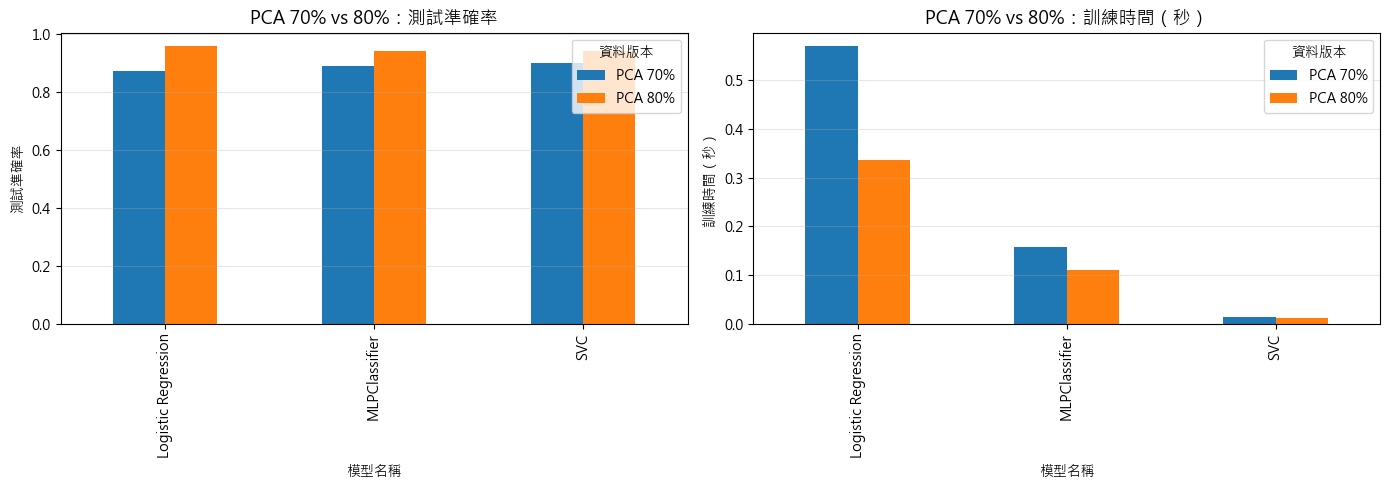

In [7]:
pca_ratio_sets = {
    "PCA 70%": (X_train_pca_70, X_test_pca_70, n_components_70),
    "PCA 80%": (X_train_pca_80, X_test_pca_80, n_components_80),
}
pca_models = {
    "Logistic Regression": LogisticRegression(C=0.1, solver="lbfgs", max_iter=10000, tol=1e-6),
    "SVC": SVC(C=0.1, kernel="linear", gamma="scale", decision_function_shape="ovo", max_iter=10000, tol=1e-6),
    "MLPClassifier": MLPClassifier(
        hidden_layer_sizes=(100,), activation="tanh", alpha=0.0001,
        solver="lbfgs", max_iter=10000, tol=1e-6, random_state=0
    ),
}

part_a_pca_rows = []
for ratio_name, (X_train_ratio, X_test_ratio, n_components) in pca_ratio_sets.items():
    for model_name, model in pca_models.items():
        start_time = time.time()
        clf = clone(model)
        clf.fit(X_train_ratio, y_train)
        elapsed = time.time() - start_time
        part_a_pca_rows.append({
            "模型名稱": model_name,
            "資料版本": ratio_name,
            "主成分數": n_components,
            "測試準確率": accuracy_score(y_test, clf.predict(X_test_ratio)),
            "訓練時間（秒）": elapsed,
        })

part_a_pca_results = pd.DataFrame(part_a_pca_rows)
display(part_a_pca_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, y_label in [
    (axes[0], "測試準確率", "測試準確率"),
    (axes[1], "訓練時間（秒）", "訓練時間（秒）"),
]:
    pivot = part_a_pca_results.pivot(index="模型名稱", columns="資料版本", values=metric)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"PCA 70% vs 80%：{y_label}", fontsize=13)
    ax.set_xlabel("模型名稱")
    ax.set_ylabel(y_label)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="資料版本")
plt.tight_layout()
plt.show()

#### <u><strong>圖表/程式碼說明：PCA 70% 與 80% 模型表現比較</strong></u>

##### **1. 概述**
本段沿用共用區塊已 fit 的主成分分析（PCA）結果，比較 70% 與 80% 累積解釋變異下三種模型的分類表現。

##### **2. 流程/設定說明**
| 比較項目 | PCA 70% | PCA 80% |
|---|---:|---:|
| 主成分來源 | 共用 `pca` 轉換後切片 | 共用 `pca` 轉換後切片 |
| 重新 fit PCA | 否 | 否 |
| 評估指標 | 測試準確率、訓練時間 | 測試準確率、訓練時間 |

##### **3. 結果觀察**
70% 與 80% 的比較可觀察降維比例對準確率與訓練效率的影響；若兩者準確率接近，較少主成分通常代表更高運算效率。

#### **<font color="blue">3. 三分類器深度評比</font>**

##### **<font color="lightblue">(1) 多元羅吉斯回歸（Multinomial Logistic Regression, MLR）</font>**


,資料版本,模型,訓練準確率,測試準確率,最佳參數,訓練時間（秒）
0,原始資料,LogisticRegressionCV,1.0,0.966667,"{'C': 0.1, 'solver': 'lbfgs'}",45.985537
1,原始資料,GridSearchCV + LR,1.0,0.966667,"{'C': 1, 'solver': 'lbfgs'}",62.776938


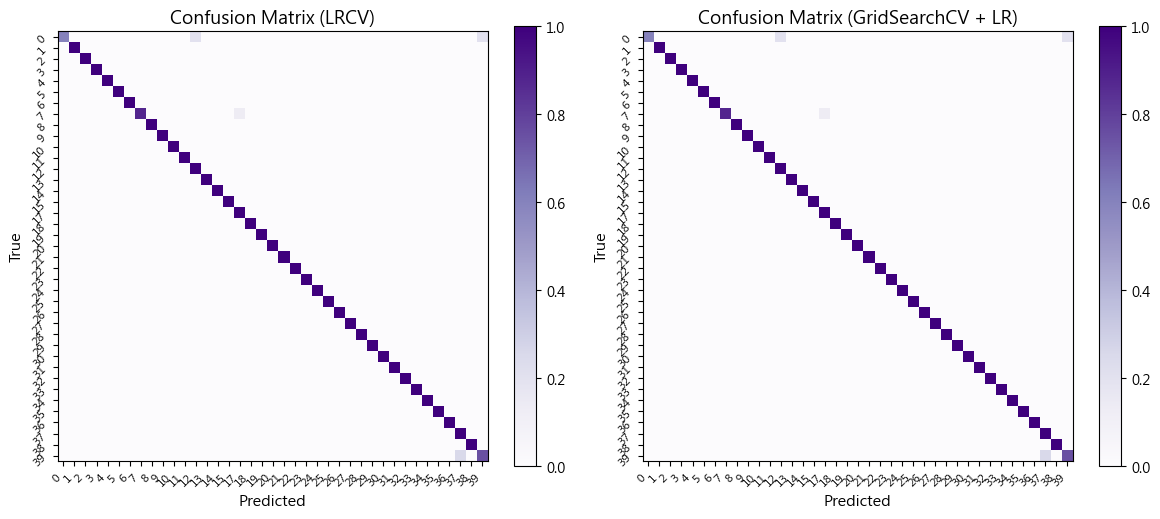

In [8]:
b_results1 = []

start_time = time.time()
clf_mlr_ori = LogisticRegressionCV(
    solver="lbfgs", Cs=[0.01, 0.1, 1, 10], cv=5,
    tol=1e-6, max_iter=int(1e6), verbose=0, n_jobs=-1
)
clf_mlr_ori.fit(X_train_original, y_train)
elapsed = time.time() - start_time
b_results1.append({
    "資料版本": "原始資料",
    "模型": "LogisticRegressionCV",
    "訓練準確率": accuracy_score(y_train, clf_mlr_ori.predict(X_train_original)),
    "測試準確率": accuracy_score(y_test, clf_mlr_ori.predict(X_test_original)),
    "最佳參數": {"C": round(clf_mlr_ori.C_[0], 4), "solver": "lbfgs"},
    "訓練時間（秒）": elapsed,
})

start_time = time.time()
b_param_grid_mlr = {"solver": ["lbfgs", "newton-cg"], "C": [0.01, 0.1, 1, 10]}
b_cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=0)
clf_mlr_grid_ori = GridSearchCV(
    estimator=LogisticRegression(tol=1e-6, max_iter=int(1e6)),
    param_grid=b_param_grid_mlr,
    scoring="accuracy",
    cv=b_cv,
    n_jobs=-1,
)
clf_mlr_grid_ori.fit(X_train_original, y_train)
elapsed = time.time() - start_time
b_best_mlr_ori = clf_mlr_grid_ori.best_estimator_
b_results1.append({
    "資料版本": "原始資料",
    "模型": "GridSearchCV + LR",
    "訓練準確率": accuracy_score(y_train, b_best_mlr_ori.predict(X_train_original)),
    "測試準確率": accuracy_score(y_test, b_best_mlr_ori.predict(X_test_original)),
    "最佳參數": clf_mlr_grid_ori.best_params_,
    "訓練時間（秒）": elapsed,
})

b_results_1 = pd.DataFrame(b_results1)
display(b_results_1)

plot_confusion_matrices(
    models=[clf_mlr_ori, clf_mlr_grid_ori.best_estimator_],
    X_tests=[X_test_original, X_test_original],
    y_test=y_test,
    titles=["LRCV", "GridSearchCV + LR"],
)

#### <u><strong>圖表/程式碼說明：MLR 原始資料策略比較</strong></u>

##### **1. 概述**
本段比較多元羅吉斯回歸（Multinomial Logistic Regression, MLR）的內建交叉驗證與 GridSearchCV 策略。

##### **2. 流程/設定說明**
| 資料版本 | 模型名稱 | 策略 | 評估內容 |
|---|---|---|---|
| 原始資料 | LogisticRegressionCV | 自動選擇 $C$ | 準確率、訓練時間、混淆矩陣 |
| 原始資料 | GridSearchCV + LR | 搜尋 `solver` 與 $C$ | 準確率、訓練時間、混淆矩陣 |

##### **3. 結果觀察**
若兩者測試準確率接近，代表此資料在線性決策邊界下已具備良好可分性；訓練時間則可作為策略取捨依據。

,資料版本,模型,訓練準確率,測試準確率,最佳參數,訓練時間（秒）
0,PCA 95%,LogisticRegressionCV,1.0,0.958333,"{'C': 1.0, 'solver': 'lbfgs'}",1.242521
1,PCA 95%,GridSearchCV + LR,1.0,0.966667,"{'C': 10, 'solver': 'lbfgs'}",1.062762


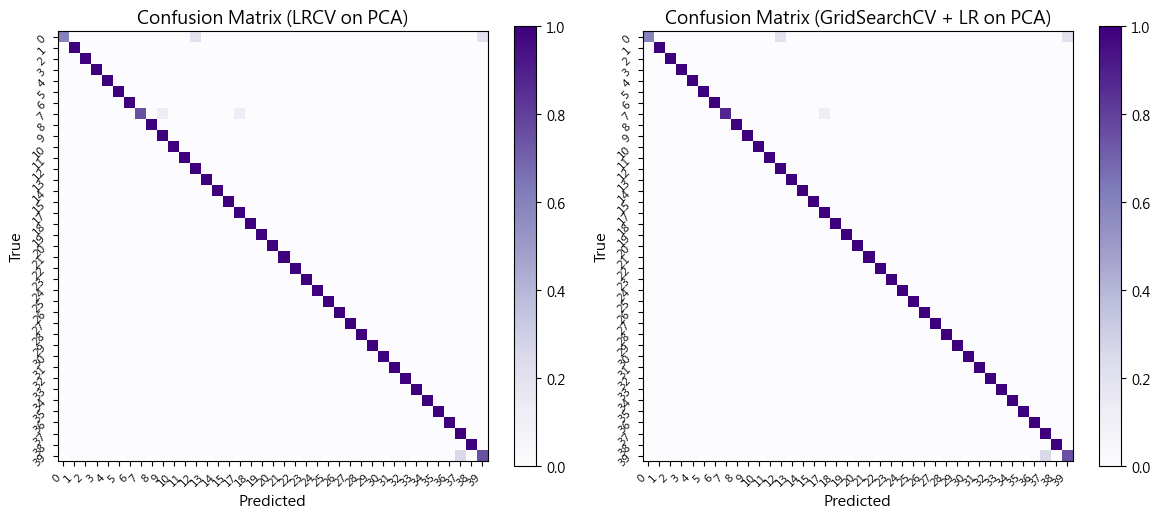

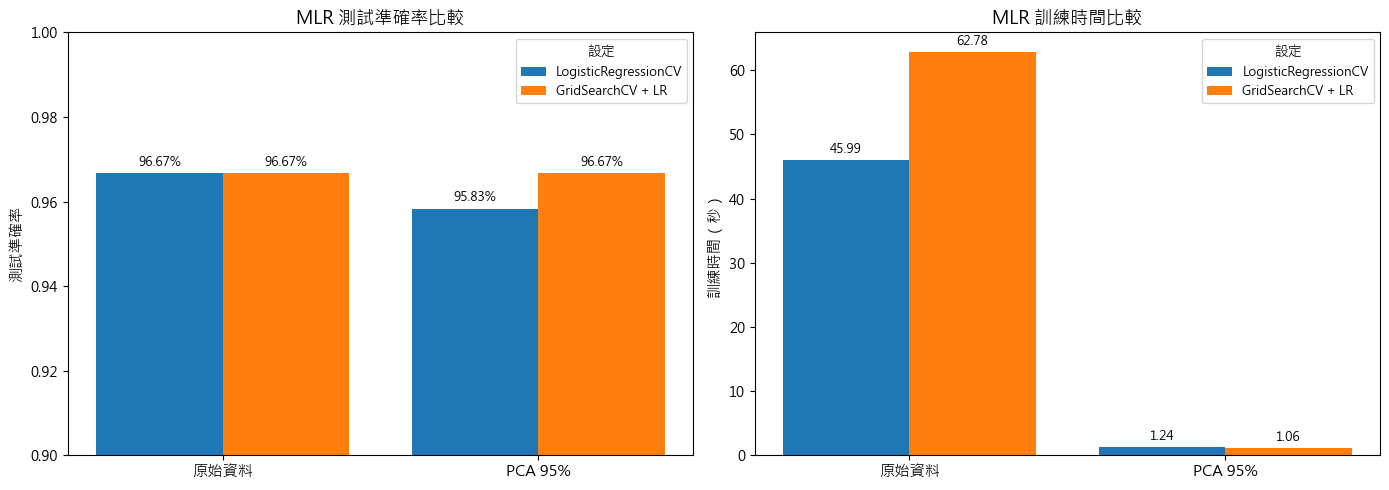

In [9]:
b_results2 = []

start_time = time.time()
clf_mlr_pca = LogisticRegressionCV(
    solver="lbfgs", Cs=[0.01, 0.1, 1, 10], cv=5,
    tol=1e-6, max_iter=int(1e6), verbose=0, n_jobs=-1
)
clf_mlr_pca.fit(X_train_pca, y_train)
elapsed = time.time() - start_time
b_results2.append({
    "資料版本": "PCA 95%",
    "模型": "LogisticRegressionCV",
    "訓練準確率": accuracy_score(y_train, clf_mlr_pca.predict(X_train_pca)),
    "測試準確率": accuracy_score(y_test, clf_mlr_pca.predict(X_test_pca)),
    "最佳參數": {"C": round(clf_mlr_pca.C_[0], 4), "solver": "lbfgs"},
    "訓練時間（秒）": elapsed,
})

start_time = time.time()
clf_mlr_grid_pca = GridSearchCV(
    estimator=LogisticRegression(tol=1e-6, max_iter=int(1e6)),
    param_grid=b_param_grid_mlr,
    scoring="accuracy",
    cv=b_cv,
    n_jobs=-1,
)
clf_mlr_grid_pca.fit(X_train_pca, y_train)
elapsed = time.time() - start_time
b_best_mlr_pca = clf_mlr_grid_pca.best_estimator_
b_results2.append({
    "資料版本": "PCA 95%",
    "模型": "GridSearchCV + LR",
    "訓練準確率": accuracy_score(y_train, b_best_mlr_pca.predict(X_train_pca)),
    "測試準確率": accuracy_score(y_test, b_best_mlr_pca.predict(X_test_pca)),
    "最佳參數": clf_mlr_grid_pca.best_params_,
    "訓練時間（秒）": elapsed,
})

b_results_2 = pd.DataFrame(b_results2)
display(b_results_2)

plot_confusion_matrices(
    models=[clf_mlr_pca, clf_mlr_grid_pca.best_estimator_],
    X_tests=[X_test_pca, X_test_pca],
    y_test=y_test,
    titles=["LRCV on PCA", "GridSearchCV + LR on PCA"],
)

df_lr = pd.concat([b_results_1, b_results_2], ignore_index=True)
df_lr_plot = df_lr.rename(columns={"模型": "設定"})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_classifier(df_lr_plot, "MLR 測試準確率比較", y_col="測試準確率",
                y_label="測試準確率", y_format="percent", y_lim=(0.9, 1), ax=axes[0])
plot_classifier(df_lr_plot, "MLR 訓練時間比較", y_col="訓練時間（秒）",
                y_label="訓練時間（秒）", y_format="float", ax=axes[1])
plt.tight_layout()
plt.show()

#### <u><strong>圖表/程式碼說明：MLR 原始資料 vs PCA 95%</strong></u>

##### **1. 概述**
本段將 MLR 的兩種策略套用在共用 PCA 95% 特徵上，並與原始資料結果比較。

##### **2. 流程/設定說明**
| 資料版本 | PCA 來源 | 模型策略 | 比較欄位 |
|---|---|---|---|
| 原始資料 | 無 | LRCV、GridSearchCV + LR | 測試準確率、訓練時間 |
| PCA 95% | 共用 `pca` 切片 | LRCV、GridSearchCV + LR | 測試準確率、訓練時間 |

##### **3. 結果觀察**
PCA 95% 通常能保留主要辨識資訊，同時降低模型訓練成本；若準確率維持接近原始資料，代表降維效果具實用價值。

##### **<font color="lightblue">(2) 支援向量機（Support Vector Machine, SVM）</font>**

,資料版本,模型,訓練準確率,測試準確率,最佳參數,訓練時間（秒）
0,原始資料,"SVM (linear, GridSearch)",1.0,0.966667,"{'C': 0.01, 'kernel': 'linear'}",0.681201
1,原始資料,"SVM (rbf, GridSearch)",1.0,0.683333,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}",1.559198


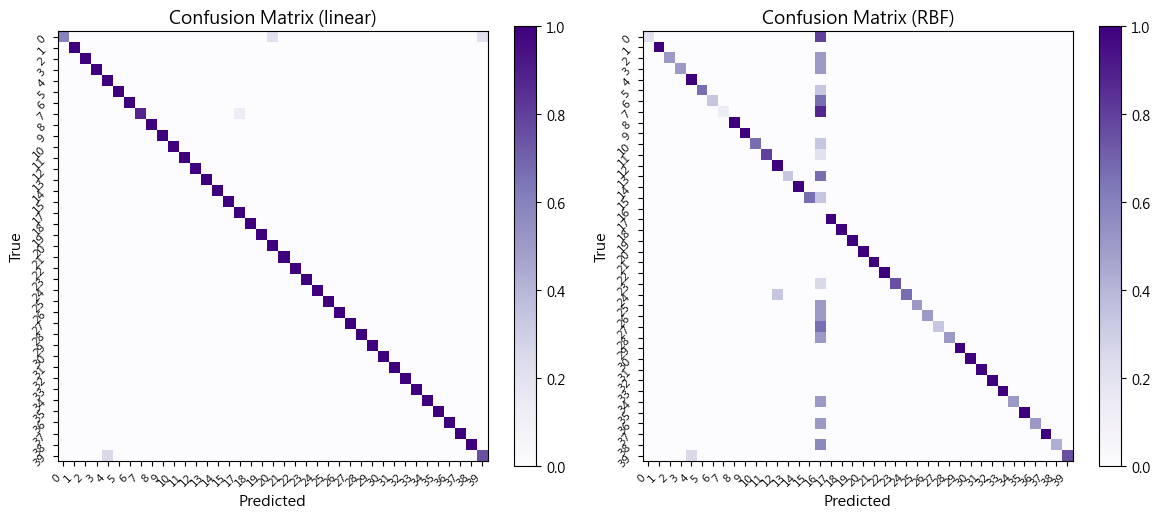

In [10]:
b_results3 = []
b_param_grid_linear = {"C": [0.01, 0.1, 1, 10, 100], "kernel": ["linear"]}
b_param_grid_rbf = {"C": [0.1, 1, 10], "gamma": [0.001, 0.01, 0.1, 1, 10], "kernel": ["rbf"]}

for label, param_grid in [("linear", b_param_grid_linear), ("rbf", b_param_grid_rbf)]:
    start_time = time.time()
    clf = GridSearchCV(
        SVC(tol=1e-6, max_iter=int(1e6)),
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
    )
    clf.fit(X_train_original, y_train)
    elapsed = time.time() - start_time
    globals()[f"clf_svm_{label}_ori"] = clf
    b_results3.append({
        "資料版本": "原始資料",
        "模型": f"SVM ({label}, GridSearch)",
        "訓練準確率": accuracy_score(y_train, clf.best_estimator_.predict(X_train_original)),
        "測試準確率": accuracy_score(y_test, clf.best_estimator_.predict(X_test_original)),
        "最佳參數": clf.best_params_,
        "訓練時間（秒）": elapsed,
    })

b_results_3 = pd.DataFrame(b_results3)
display(b_results_3)

plot_confusion_matrices(
    models=[clf_svm_linear_ori.best_estimator_, clf_svm_rbf_ori.best_estimator_],
    X_tests=[X_test_original, X_test_original],
    y_test=y_test,
    titles=["linear", "RBF"],
)

#### <u><strong>圖表/程式碼說明：SVM 原始資料策略比較</strong></u>

##### **1. 概述**
本段比較支援向量機（Support Vector Machine, SVM）的線性核函數與徑向基底函數（RBF）核函數。

##### **2. 流程/設定說明**
| 資料版本 | 核函數 | 搜尋參數 | 評估內容 |
|---|---|---|---|
| 原始資料 | linear | $C$ | 準確率、訓練時間、混淆矩陣 |
| 原始資料 | RBF | $C$、$\gamma$ | 準確率、訓練時間、混淆矩陣 |

##### **3. 結果觀察**
高維人臉資料常讓線性核函數有穩定表現；RBF 核函數雖具非線性能力，但也較容易受參數與資料規模影響。

,資料版本,模型,訓練準確率,測試準確率,最佳參數,訓練時間（秒）
0,PCA 95%,"SVM (linear, GridSearch)",1.0,0.966667,"{'C': 0.01, 'kernel': 'linear'}",0.084706
1,PCA 95%,"SVM (rbf, GridSearch)",1.0,0.825000,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}",0.180566


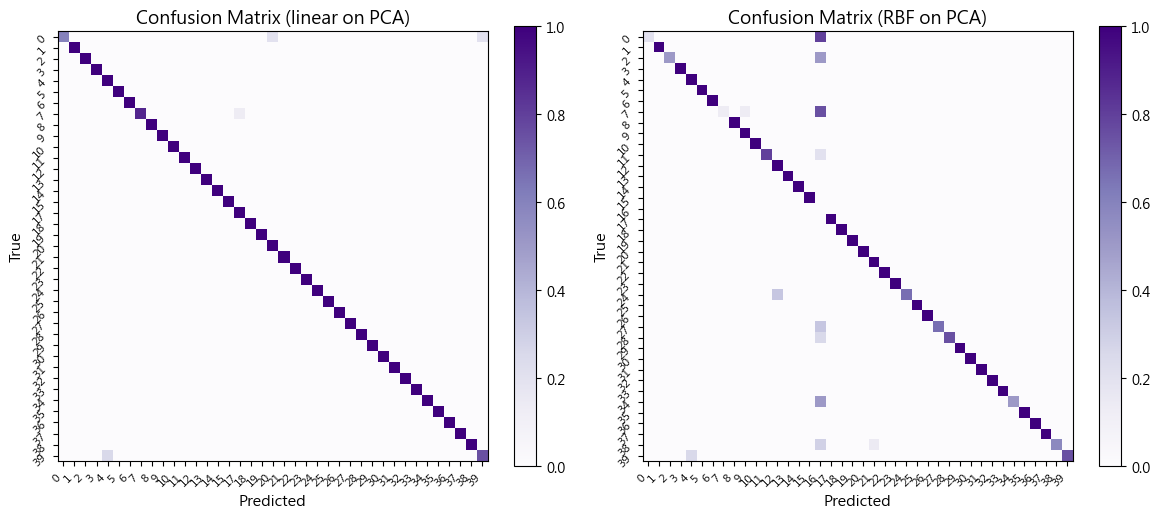

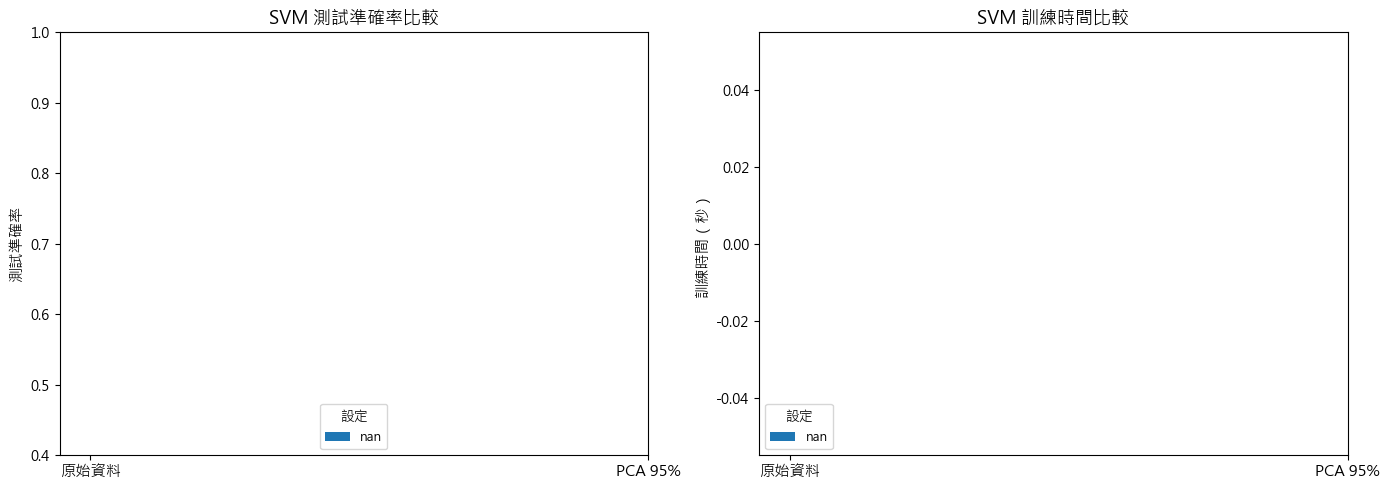

In [11]:
b_results4 = []

for label, param_grid in [("linear", b_param_grid_linear), ("rbf", b_param_grid_rbf)]:
    start_time = time.time()
    clf = GridSearchCV(
        SVC(tol=1e-6, max_iter=int(1e6)),
        param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
    )
    clf.fit(X_train_pca, y_train)
    elapsed = time.time() - start_time
    globals()[f"clf_svm_{label}_pca"] = clf
    b_results4.append({
        "資料版本": "PCA 95%",
        "模型": f"SVM ({label}, GridSearch)",
        "訓練準確率": accuracy_score(y_train, clf.best_estimator_.predict(X_train_pca)),
        "測試準確率": accuracy_score(y_test, clf.best_estimator_.predict(X_test_pca)),
        "最佳參數": clf.best_params_,
        "訓練時間（秒）": elapsed,
    })

b_results_4 = pd.DataFrame(b_results4)
display(b_results_4)

plot_confusion_matrices(
    models=[clf_svm_linear_pca.best_estimator_, clf_svm_rbf_pca.best_estimator_],
    X_tests=[X_test_pca, X_test_pca],
    y_test=y_test,
    titles=["linear on PCA", "RBF on PCA"],
)

df_svm = pd.concat([b_results_3, b_results_4], ignore_index=True)
df_svm_plot = df_svm.assign(設定=df_svm["模型"].str.extract(r"SVM \\((.*), GridSearch\\)")[0].str.upper())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_classifier(df_svm_plot, "SVM 測試準確率比較", y_col="測試準確率",
                y_label="測試準確率", y_format="percent", y_lim=(0.4, 1), ax=axes[0])
plot_classifier(df_svm_plot, "SVM 訓練時間比較", y_col="訓練時間（秒）",
                y_label="訓練時間（秒）", y_format="float", ax=axes[1])
plt.tight_layout()
plt.show()

#### <u><strong>圖表/程式碼說明：SVM 原始資料 vs PCA 95%</strong></u>

##### **1. 概述**
本段比較 SVM 在線性核函數與 RBF 核函數下，使用原始資料與 PCA 95% 資料的效能差異。

##### **2. 流程/設定說明**
| 資料版本 | PCA 來源 | 比較策略 | 比較欄位 |
|---|---|---|---|
| 原始資料 | 無 | linear、RBF | 測試準確率、訓練時間 |
| PCA 95% | 共用 `pca` 切片 | linear、RBF | 測試準確率、訓練時間 |

##### **3. 結果觀察**
若 PCA 後線性核函數仍維持高準確率，代表主要判別方向已由少量主成分保留；RBF 的改善與否則可反映降維對非線性模型的幫助程度。

##### **<font color="lightblue">(3) 神經網路（Neural Network, NN）</font>**

,資料版本,模型,訓練準確率,測試準確率,最佳參數,訓練時間（秒）
0,原始資料,"NN (relu, GridSearch)",1.0,0.900000,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",37.919365
1,原始資料,"NN (tanh, GridSearch)",1.0,0.941667,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",138.963123


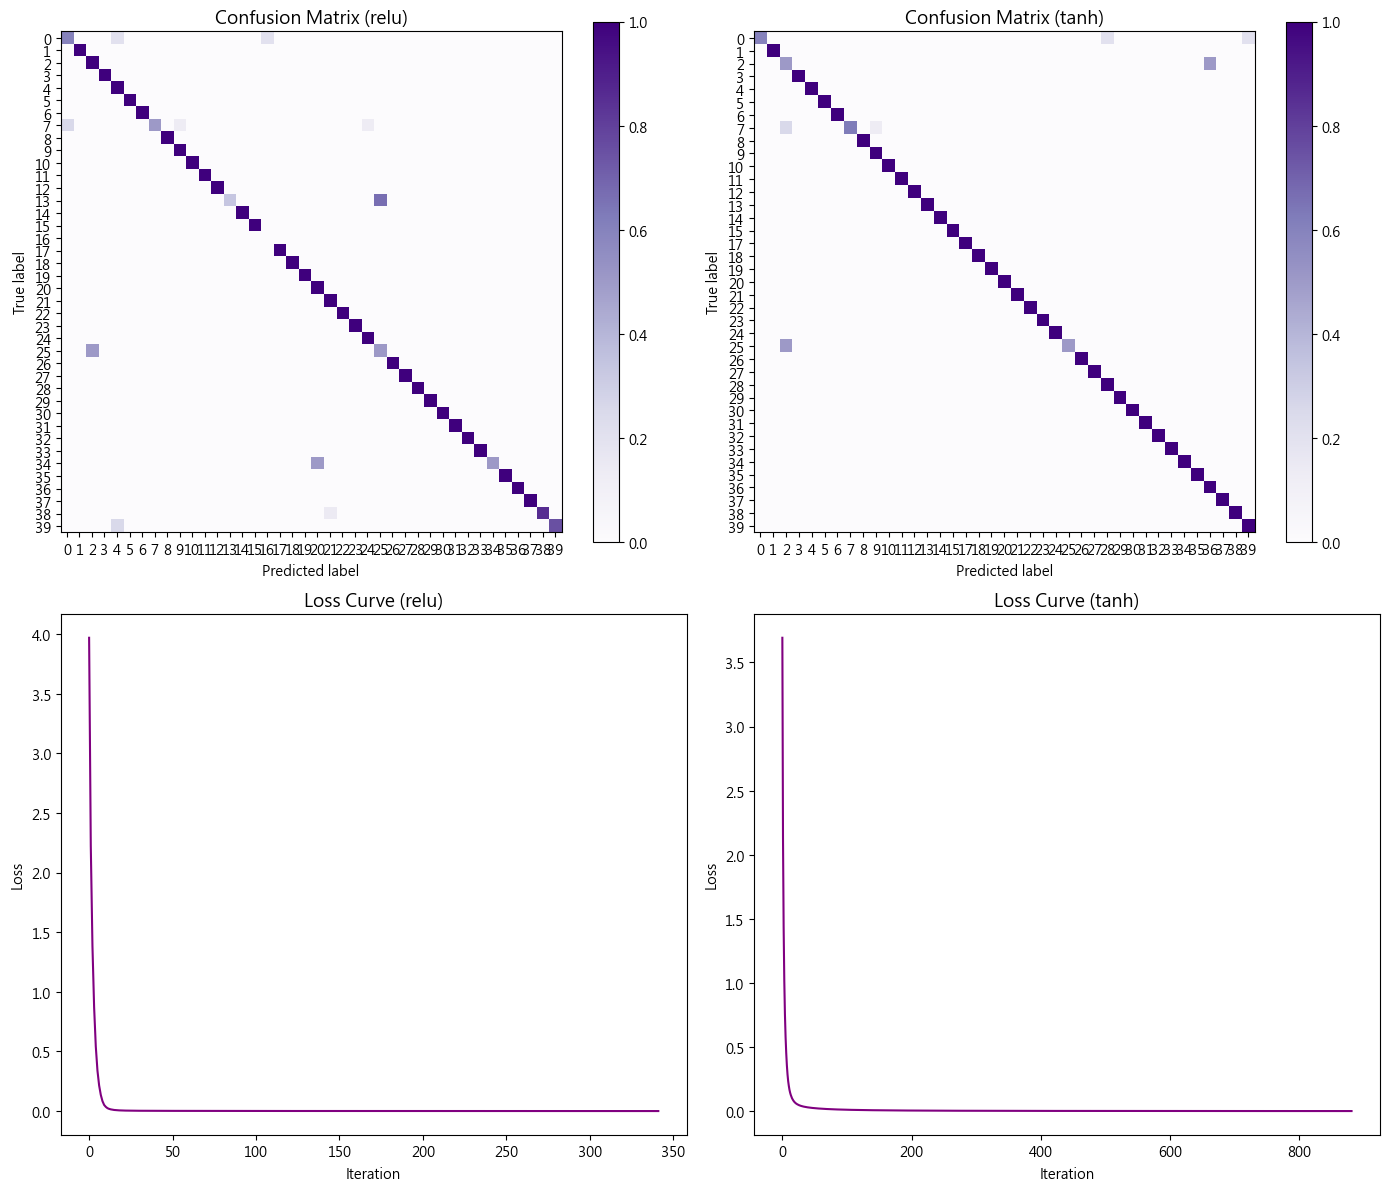

In [12]:
b_results5 = []
b_param_grid_relu_ori = {
    "hidden_layer_sizes": [(100,), (128, 64)],
    "learning_rate_init": [0.0005],
    "alpha": [0.0001, 0.001],
    "solver": ["adam"],
    "activation": ["relu"],
    "learning_rate": ["adaptive"],
}
b_param_grid_tanh_ori = {**b_param_grid_relu_ori, "activation": ["tanh"]}

for label, param_grid in [("relu", b_param_grid_relu_ori), ("tanh", b_param_grid_tanh_ori)]:
    start_time = time.time()
    clf = GridSearchCV(
        MLPClassifier(max_iter=int(1e6), tol=1e-6, random_state=0),
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1,
    )
    clf.fit(X_train_original, y_train)
    elapsed = time.time() - start_time
    globals()[f"clf_nn_{label}_ori"] = clf
    b_results5.append({
        "資料版本": "原始資料",
        "模型": f"NN ({label}, GridSearch)",
        "訓練準確率": accuracy_score(y_train, clf.best_estimator_.predict(X_train_original)),
        "測試準確率": accuracy_score(y_test, clf.best_estimator_.predict(X_test_original)),
        "最佳參數": clf.best_params_,
        "訓練時間（秒）": elapsed,
    })

b_results_5 = pd.DataFrame(b_results5)
display(b_results_5)

y_pred_relu = clf_nn_relu_ori.best_estimator_.predict(X_test_original)
y_pred_tanh = clf_nn_tanh_ori.best_estimator_.predict(X_test_original)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_relu, normalize="true", cmap=plt.cm.Purples,
                                         ax=axes[0, 0], include_values=False)
axes[0, 0].set_title("Confusion Matrix (relu)", fontsize=13)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tanh, normalize="true", cmap=plt.cm.Purples,
                                         ax=axes[0, 1], include_values=False)
axes[0, 1].set_title("Confusion Matrix (tanh)", fontsize=13)
axes[1, 0].plot(clf_nn_relu_ori.best_estimator_.loss_curve_, color="purple")
axes[1, 0].set_title("Loss Curve (relu)", fontsize=13)
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Loss")
axes[1, 1].plot(clf_nn_tanh_ori.best_estimator_.loss_curve_, color="purple")
axes[1, 1].set_title("Loss Curve (tanh)", fontsize=13)
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Loss")
plt.tight_layout()
plt.show()

#### <u><strong>圖表/程式碼說明：NN 原始資料策略比較</strong></u>

##### **1. 概述**
本段比較神經網路（Neural Network, NN）在 ReLU 與 tanh 兩種激活函數下的分類表現。

##### **2. 流程/設定說明**
| 資料版本 | 激活函數 | 搜尋參數 | 評估內容 |
|---|---|---|---|
| 原始資料 | ReLU | 隱藏層、正則化強度、學習率 | 準確率、訓練時間、混淆矩陣、Loss 曲線 |
| 原始資料 | tanh | 隱藏層、正則化強度、學習率 | 準確率、訓練時間、混淆矩陣、Loss 曲線 |

##### **3. 結果觀察**
神經網路可學習非線性關係，但在小樣本高維影像資料上較容易受到模型結構、初始化與正則化設定影響。

,資料版本,模型,訓練準確率,測試準確率,最佳參數,訓練時間（秒）
0,PCA 95%,"NN (relu, GridSearch)",1.0,0.866667,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",5.686499
1,PCA 95%,"NN (tanh, GridSearch)",1.0,0.908333,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",14.445417


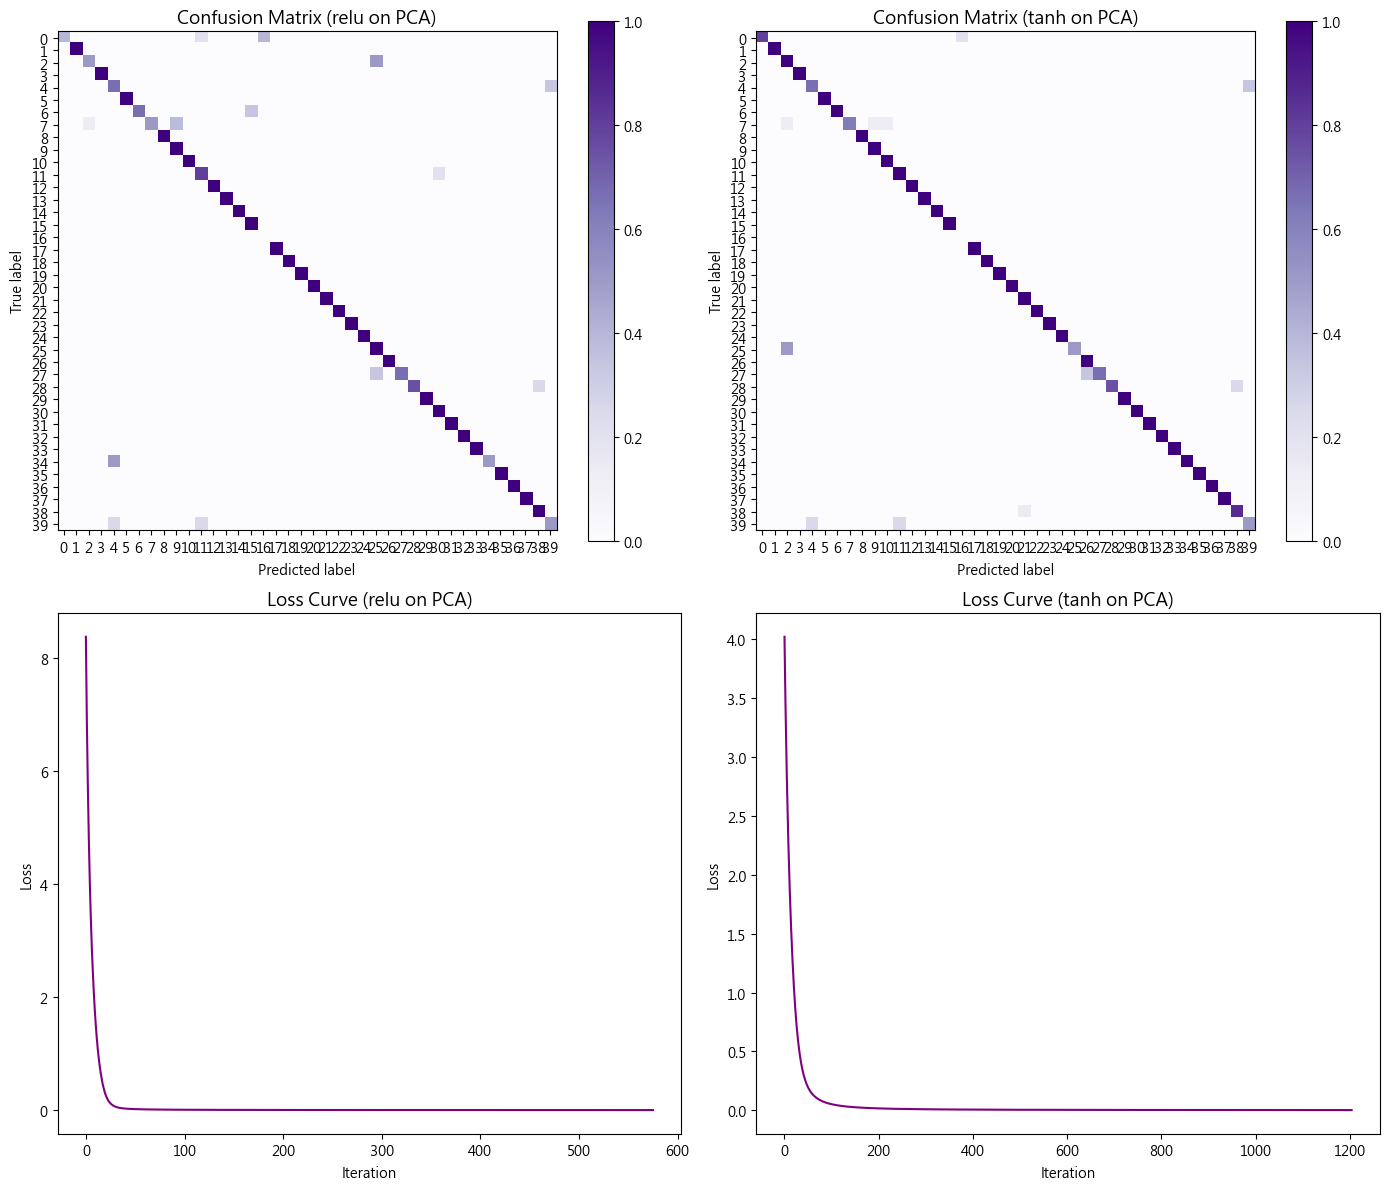

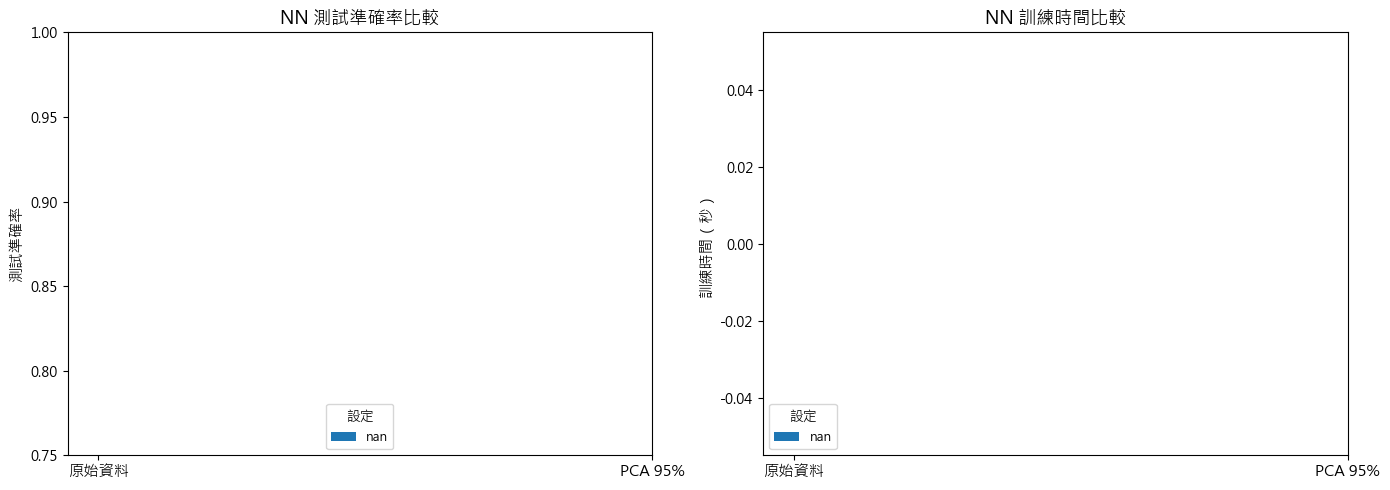

In [13]:
b_results6 = []
b_param_grid_relu_pca = {
    "hidden_layer_sizes": [(100,), (128, 64)],
    "learning_rate_init": [0.0005, 0.001],
    "alpha": [0.0001, 0.001],
    "solver": ["adam"],
    "activation": ["relu"],
    "learning_rate": ["adaptive"],
}
b_param_grid_tanh_pca = {**b_param_grid_relu_pca, "activation": ["tanh"]}

for label, param_grid in [("relu", b_param_grid_relu_pca), ("tanh", b_param_grid_tanh_pca)]:
    start_time = time.time()
    clf = GridSearchCV(
        MLPClassifier(max_iter=int(1e6), tol=1e-6, random_state=0),
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1,
    )
    clf.fit(X_train_pca, y_train)
    elapsed = time.time() - start_time
    globals()[f"clf_nn_{label}_pca"] = clf
    b_results6.append({
        "資料版本": "PCA 95%",
        "模型": f"NN ({label}, GridSearch)",
        "訓練準確率": accuracy_score(y_train, clf.best_estimator_.predict(X_train_pca)),
        "測試準確率": accuracy_score(y_test, clf.best_estimator_.predict(X_test_pca)),
        "最佳參數": clf.best_params_,
        "訓練時間（秒）": elapsed,
    })

b_results_6 = pd.DataFrame(b_results6)
display(b_results_6)

y_pred_relu = clf_nn_relu_pca.best_estimator_.predict(X_test_pca)
y_pred_tanh = clf_nn_tanh_pca.best_estimator_.predict(X_test_pca)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_relu, normalize="true", cmap=plt.cm.Purples,
                                         ax=axes[0, 0], include_values=False)
axes[0, 0].set_title("Confusion Matrix (relu on PCA)", fontsize=13)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tanh, normalize="true", cmap=plt.cm.Purples,
                                         ax=axes[0, 1], include_values=False)
axes[0, 1].set_title("Confusion Matrix (tanh on PCA)", fontsize=13)
axes[1, 0].plot(clf_nn_relu_pca.best_estimator_.loss_curve_, color="purple")
axes[1, 0].set_title("Loss Curve (relu on PCA)", fontsize=13)
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Loss")
axes[1, 1].plot(clf_nn_tanh_pca.best_estimator_.loss_curve_, color="purple")
axes[1, 1].set_title("Loss Curve (tanh on PCA)", fontsize=13)
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Loss")
plt.tight_layout()
plt.show()

df_nn = pd.concat([b_results_5, b_results_6], ignore_index=True)
df_nn_plot = df_nn.assign(設定=df_nn["模型"].str.extract(r"NN \\((.*), GridSearch\\)")[0])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_classifier(df_nn_plot, "NN 測試準確率比較", y_col="測試準確率",
                y_label="測試準確率", y_format="percent", y_lim=(0.75, 1), ax=axes[0])
plot_classifier(df_nn_plot, "NN 訓練時間比較", y_col="訓練時間（秒）",
                y_label="訓練時間（秒）", y_format="float", ax=axes[1])
plt.tight_layout()
plt.show()

#### <u><strong>圖表/程式碼說明：NN 原始資料 vs PCA 95%</strong></u>

##### **1. 概述**
本段比較 NN 在原始資料與 PCA 95% 資料上的分類表現，並觀察 ReLU 與 tanh 的泛化差異。

##### **2. 流程/設定說明**
| 資料版本 | PCA 來源 | 激活函數 | 比較欄位 |
|---|---|---|---|
| 原始資料 | 無 | ReLU、tanh | 測試準確率、訓練時間、Loss 曲線 |
| PCA 95% | 共用 `pca` 切片 | ReLU、tanh | 測試準確率、訓練時間、Loss 曲線 |

##### **3. 結果觀察**
PCA 可降低輸入維度並縮短訓練時間，但若主成分保留不足或模型容量不穩定，神經網路的測試準確率可能低於線性模型。

#### **<font color="blue">4. 整合結論</font>**

In [14]:
def _collect_summary(df, part_name):
    out = df.copy()
    out["資料集"] = "AT&T Face Dataset"
    out["分析段落"] = part_name
    return out

summary_tables = [
    _collect_summary(part_a_pca_results.rename(columns={"模型名稱": "模型"}), "模型與 PCA 比例分析"),
    _collect_summary(df_lr, "三分類器深度評比：MLR"),
    _collect_summary(df_svm, "三分類器深度評比：SVM"),
    _collect_summary(df_nn, "三分類器深度評比：NN"),
]

combined_summary = pd.concat(summary_tables, ignore_index=True)
summary_columns = ["資料集", "分析段落", "模型", "資料版本", "測試準確率", "訓練時間（秒）"]
combined_summary = combined_summary[summary_columns]
display(combined_summary)

,資料集,分析段落,模型,資料版本,測試準確率,訓練時間（秒）
0,AT&T Face Dataset,模型與 PCA 比例分析,Logistic Regression,PCA 70%,0.875000,0.569446
1,AT&T Face Dataset,模型與 PCA 比例分析,SVC,PCA 70%,0.900000,0.013232
2,AT&T Face Dataset,模型與 PCA 比例分析,MLPClassifier,PCA 70%,0.891667,0.157367
3,AT&T Face Dataset,模型與 PCA 比例分析,Logistic Regression,PCA 80%,0.958333,0.335264
4,AT&T Face Dataset,模型與 PCA 比例分析,SVC,PCA 80%,0.941667,0.010627
5,AT&T Face Dataset,模型與 PCA 比例分析,MLPClassifier,PCA 80%,0.941667,0.110009
6,AT&T Face Dataset,三分類器深度評比：MLR,LogisticRegressionCV,原始資料,0.966667,45.985537
7,AT&T Face Dataset,三分類器深度評比：MLR,GridSearchCV + LR,原始資料,0.966667,62.776938
8,AT&T Face Dataset,三分類器深度評比：MLR,LogisticRegressionCV,PCA 95%,0.958333,1.242521
9,AT&T Face Dataset,三分類器深度評比：MLR,GridSearchCV + LR,PCA 95%,0.966667,1.062762


#### <u><strong>整合結論：PCA 比例影響與三分類器取捨</strong></u>

##### **1. 關鍵數字總表**
上方總表彙整 AT&T 人臉資料集在不同模型、資料版本與分析段落中的測試準確率與訓練時間。

##### **2. PCA 比例影響**
| 比較面向 | PCA 70% | PCA 80% | PCA 95% |
|---|---|---|---|
| 維度壓縮 | 主成分數最少，訓練效率最佳 | 在資訊保留與效率間折衷 | 保留資訊最多，接近原始資料 |
| 準確率風險 | 可能損失部分辨識細節 | 通常較 70% 穩定 | 通常最接近原始特徵表現 |
| 適用情境 | 快速實驗、效率優先 | 效率與準確率兼顧 | 準確率與穩定性優先 |

##### **3. 三分類器取捨**
| 分類器 | 測試準確率表現 | 訓練時間效率 | 過擬合風險 | 解釋性 |
|---|---|---|---|---|
| 多元羅吉斯回歸（MLR） | 通常穩定且接近最佳 | PCA 後效率提升明顯 | 較低 | 高 |
| 支援向量機（SVM） | 線性核函數在高維人臉資料上表現穩定 | 線性核函數通常較有效率 | RBF 較高 | 中 |
| 神經網路（NN） | 受 activation 與結構影響較大 | 原始高維資料較耗時 | 較高 | 較低 |

##### **4. 綜合討論**
整體而言，AT&T 人臉資料集雖然原始維度高達 4096，但樣本數僅 400，因此線性模型在標準化後已能取得穩定分類效果。主成分分析（PCA）提供了有效的維度壓縮方式：70% 與 80% 適合觀察資訊保留比例對準確率的影響，95% 則適合作為接近原始資料但降低計算成本的折衷設定。若以準確率、訓練時間與解釋性綜合評估，多元羅吉斯回歸（MLR）與線性支援向量機（SVM）較適合作為本資料集的主要模型；神經網路（NN）雖具彈性，但在小樣本高維資料上需要更謹慎的正則化與模型選擇。